# Summary
Author: Ethan Feldman (erf6575@rit.edu)

This notebook walks you through the implementation of the GED score on the Iris dataset. The following sections detail to steps to produce a GED score, visualitations of decision trees and graphs, and the comparision of GED score to common accuracy metrics.

In [1]:
# Core imports and global configuration
# - Load libraries for data handling, plotting, and tree/graph utilities
# - Configure project path and random seed
import os
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

from sklearn import tree
import networkx as nx
from TreeHelp import Node
from TreeScores import Dataset, build_zss_tree, tree_to_digraph, print_tree, getScores

# Base path for loading the different CSV versions of the Iris dataset
# PATH = "/home/erf6575/Desktop/SynthData/"
PATH = os.getcwd() + "/"
SEED = 42

# Implementation on Iris dataset

In [2]:
# Load each version of the Iris dataset (original and synthetic variants)
df_o = Dataset(PATH + "data/iris_original.csv", "original")
df_g = Dataset(PATH + "data/iris_gc.csv", "GaussianCopula")
df_c = Dataset(PATH + "data/iris_ctgan.csv", "CTGAN")
df_p = Dataset(PATH + "data/iris_pate.csv", "PATEGAN")
df_b = Dataset(PATH + "data/iris_pb.csv", "PrivBayes")


# Train one decision tree per dataset to compare predictive performance
clf_original = DecisionTreeClassifier(random_state=42)
clf_original.fit(df_o.x_train, df_o.y_train)

clf_gc = DecisionTreeClassifier(random_state=42)
clf_gc.fit(df_g.x_train, df_g.y_train)

clf_ctgan = DecisionTreeClassifier(random_state=42)
clf_ctgan.fit(df_c.x_train, df_c.y_train)

clf_pate = DecisionTreeClassifier(random_state=42)
clf_pate.fit(df_p.x_train, df_p.y_train)

clf_pb = DecisionTreeClassifier(random_state=42)
clf_pb.fit(df_b.x_train, df_b.y_train)


# Compare weighted F1 scores (accounts for class imbalance) across datasets
print("Orginial F1:", f1_score(df_o.y_test, clf_original.predict(df_o.x_test), average='weighted'))
print("GC F1:", f1_score(df_g.y_test, clf_gc.predict(df_g.x_test), average='weighted'))
print("CTGAN F1:", f1_score(df_c.y_test, clf_ctgan.predict(df_c.x_test), average='weighted'))
print("PATE F1:", f1_score(df_p.y_test, clf_pate.predict(df_p.x_test), average='weighted'))
print("PB F1:", f1_score(df_b.y_test, clf_pb.predict(df_b.x_test), average='weighted'))

Orginial F1: 0.9333333333333333
GC F1: 0.532063492063492
CTGAN F1: 0.3009090909090909
PATE F1: 0.7282913165266106
PB F1: 0.24055555555555555


# Decision Trees and Graphs

In [3]:
# Getting the decision trees for each dataset
tree_original = build_zss_tree(clf_original.tree_)
tree_gc = build_zss_tree(clf_gc.tree_)
tree_ctgan = build_zss_tree(clf_ctgan.tree_)
tree_pate = build_zss_tree(clf_pate.tree_)
tree_pb = build_zss_tree(clf_pb.tree_)

# Converting the decision trees for each dataset to graph representations
graph_original = tree_to_digraph(tree_original, df_o.n_obs)
graph_gc = tree_to_digraph(tree_gc, df_g.n_obs)
graph_ctgan = tree_to_digraph(tree_ctgan, df_c.n_obs)
graph_pate = tree_to_digraph(tree_pate, df_p.n_obs)
graph_pb = tree_to_digraph(tree_pb, df_b.n_obs)

[Text(0.4, 0.9166666666666666, 'x[2] <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 40, 40]'),
 Text(0.3, 0.75, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'x[3] <= 1.65\ngini = 0.5\nsamples = 80\nvalue = [0, 40, 40]'),
 Text(0.45, 0.8333333333333333, '  False'),
 Text(0.2, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.133\nsamples = 42\nvalue = [0, 39, 3]'),
 Text(0.1, 0.4166666666666667, 'gini = 0.0\nsamples = 38\nvalue = [0, 38, 0]'),
 Text(0.3, 0.4166666666666667, 'x[0] <= 6.15\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.2, 0.25, 'x[1] <= 2.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.1, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.3, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.4, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]'),
 Text(0.8, 0.5833333333333334, 'x[2] <= 4.85\ngini = 0.051\nsamples = 38\nvalue = [0, 1, 37]'),
 

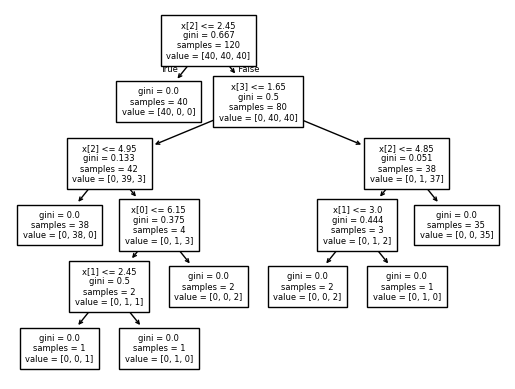

In [4]:
# Showing the decision tree of a decision tree classifier on the original iris data 
tree.plot_tree(clf_original, fontsize=6)

Node(label=2, value=[[0.33333333 0.33333333 0.33333333]])
  Node(label=Class_0, value=[[1. 0. 0.]])
  Node(label=3, value=[[0.  0.5 0.5]])
    Node(label=2, value=[[0.         0.92857143 0.07142857]])
      Node(label=Class_1, value=[[0. 1. 0.]])
      Node(label=0, value=[[0.   0.25 0.75]])
        Node(label=1, value=[[0.  0.5 0.5]])
          Node(label=Class_2, value=[[0. 0. 1.]])
          Node(label=Class_1, value=[[0. 1. 0.]])
        Node(label=Class_2, value=[[0. 0. 1.]])
    Node(label=2, value=[[0.         0.02631579 0.97368421]])
      Node(label=1, value=[[0.         0.33333333 0.66666667]])
        Node(label=Class_2, value=[[0. 0. 1.]])
        Node(label=Class_1, value=[[0. 1. 0.]])
      Node(label=Class_2, value=[[0. 0. 1.]])


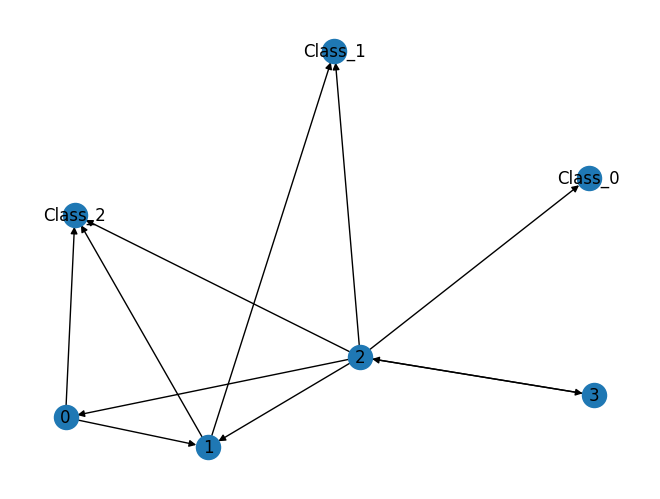

In [5]:
# Showing the decision graph of a decision tree classifier on the original iris data 
print_tree(tree_original)
nx.draw(graph_original, with_labels=True)

In [6]:
# Nodes represent features or classes.
# Nodes contain the average summary of the training samples that reached said node.
graph_original.nodes[2]

{'label': 2, 'value': array([[0.11111111, 0.42940685, 0.45948204]])}

In [7]:
# Edges represent decision traversal.
# Edges contain the number of visits between said nodes.
graph_original[0][1]

{'path': '[0][1]', 'weight': 0.006666666666666667}

# Scores

Accuracy: Proportion of all predictions that are exactly correct (true positives and true negatives over all samples).

F1: Harmonic mean of precision and recall, summarizing how well the model balances missing positives vs false alarms.

AUC: Area under the ROC curve, measuring how well the model ranks positives above negatives across all classification thresholds.

Graph Edit Distance (GED): Measures how dissimilar two graphs are by counting the minimum-cost sequence of node and edge insertions, deletions, or substitutions needed to transform one graph into the other.

GED Score (Proposed): Represented as the inverse of GED / sum of nodes and edges between g1 and g2. Provides a score between 0 - 1 given that the worst case is deleting and rebuilding all nodes/edges to make g1 into g2. 

In [8]:
# Getting GED 
# scores_df = pd.DataFrame(columns=['synthesizer', 'accuracy', 'f1', 'auc', 'ged', 'ged_score'])

# Compare each data synthesizer to original data
scores_original = getScores(clf_original, df_o, graph_original)
scores_gc = getScores(clf_gc, df_g, graph_original)
scores_ctgan = getScores(clf_ctgan, df_c, graph_original)
scores_pate = getScores(clf_pate, df_p, graph_original)
scores_pb = getScores(clf_pb, df_b, graph_original)

# Combine
scores_df = pd.concat([scores_original, scores_gc, scores_ctgan, scores_pate, scores_pb], ignore_index=True)

print(scores_df)

      synthesizer  accuracy        f1       auc        ged  ged_score
0        original  0.933333  0.933333  0.950000   0.000000   1.000000
1  GaussianCopula  0.533333  0.514286  0.635417  17.965893   0.661021
2           CTGAN  0.300000  0.302020  0.476515  17.867879   0.662870
3         PATEGAN  0.766667  0.382820  0.541667  14.916401   0.701672
4       PrivBayes  0.233333  0.238889  0.423737  18.171938   0.657133
